---
## Etape 0 - Chargement des donnees <a id='etape0'></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model    import LinearRegression, Ridge
from sklearn.ensemble        import RandomForestRegressor
from sklearn.preprocessing   import StandardScaler, LabelEncoder
from sklearn.metrics         import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score
import xgboost as xgb
import shap

from IPython.display import display

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14

print("Librairies importees")

Librairies importees


In [2]:
# Chargement des fichiers nettoyés
customers_clean = pd.read_csv('customers_clean.csv')
txn_clean       = pd.read_csv('transactions_clean.csv')
rfm_segmented   = pd.read_csv('rfm_segmented_final.csv')
returns         = pd.read_csv('returns.csv')

# Reconversion des dates
customers_clean['first_purchase'] = pd.to_datetime(customers_clean['first_purchase'])
customers_clean['last_purchase']  = pd.to_datetime(customers_clean['last_purchase'])
txn_clean['invoice_date']         = pd.to_datetime(txn_clean['invoice_date'])
returns['invoice_date']           = pd.to_datetime(returns['invoice_date'])

# Garantir le bon type
customers_clean['is_b2b_suspect'] = customers_clean['is_b2b_suspect'].astype(bool)

# On travaille uniquement avec les clients identifiés
txn_id = txn_clean[~txn_clean['is_anonymous']].copy()

print(f"customers_clean : {len(customers_clean):,} clients")
print(f"txn_clean       : {len(txn_clean):,} lignes")
print(f"txn_id          : {len(txn_id):,} lignes (clients identifiés)")
print(f"returns         : {len(returns):,} lignes (retours)")
print(f"Période         : {txn_id['invoice_date'].min().date()} -> {txn_id['invoice_date'].max().date()}")


customers_clean : 50,000 clients
txn_clean       : 1,756,557 lignes
txn_id          : 1,357,701 lignes (clients identifiés)
returns         : 22,860 lignes (retours)
Période         : 2007-07-06 -> 2011-12-09


---
## Étape 1 — CLV historique & création de la target <a id='etape1'></a>

### 1.1 Définition du split temporel


In [3]:
# Définition des périodes
date_min = txn_id['invoice_date'].min()
date_max = txn_id['invoice_date'].max()

print(f"Début du dataset : {date_min.date()}")
print(f"Fin du dataset   : {date_max.date()}")
print(f"Durée totale     : {(date_max - date_min).days} jours")

# Split 24 mois observation / 12 mois cible
# (12 mois donnait ~6 500 clients en observation = trop peu, R² ~ 0)
OBS_START  = date_min
OBS_END    = date_min + pd.DateOffset(months=24)
TARGET_END = OBS_END  + pd.DateOffset(months=12)

print(f"Période d'observation : {OBS_START.date()} -> {OBS_END.date()} (24 mois)")
print(f"Période cible         : {OBS_END.date()} -> {TARGET_END.date()} (12 mois)")

# Vérification du volume de données disponible
txn_target_check = txn_id[(txn_id['invoice_date'] > OBS_END) &
                           (txn_id['invoice_date'] <= TARGET_END)]
print(f"Transactions en période cible : {len(txn_target_check):,}")
print(f"Clients en période cible      : {txn_target_check['customer_id'].nunique():,}")


Début du dataset : 2007-07-06
Fin du dataset   : 2011-12-09
Durée totale     : 1617 jours
Période d'observation : 2007-07-06 -> 2009-07-06 (24 mois)
Période cible         : 2009-07-06 -> 2010-07-06 (12 mois)
Transactions en période cible : 367,168
Clients en période cible      : 24,682


In [4]:
# Separation des transactions par periode
txn_obs    = txn_id[(txn_id['invoice_date'] >= OBS_START) & 
                     (txn_id['invoice_date'] <  OBS_END)].copy()
txn_target = txn_id[(txn_id['invoice_date'] >= OBS_END) & 
                     (txn_id['invoice_date'] <  TARGET_END)].copy()

print(f"txn_obs    : {len(txn_obs):,} lignes | {txn_obs['customer_id'].nunique():,} clients uniques")
print(f"txn_target : {len(txn_target):,} lignes | {txn_target['customer_id'].nunique():,} clients uniques")

txn_obs    : 30,604 lignes | 6,524 clients uniques
txn_target : 366,601 lignes | 24,651 clients uniques


### 1.2 Calcul de la target (CLV periode cible)

In [5]:
# CLV target = somme des line_total sur la periode cible par client
clv_target = (
    txn_target
    .groupby('customer_id')['line_total']
    .sum()
    .reset_index()
    .rename(columns={'line_total': 'clv_target'})
)

print(f"Clients avec CLV target > 0 : {len(clv_target):,}")
print()
print("Distribution de la CLV target :")
display(clv_target['clv_target'].describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99]).round(2))

Clients avec CLV target > 0 : 24,651

Distribution de la CLV target :


count     24651.00
mean        342.92
std        2082.49
min           0.19
25%          27.15
50%          71.16
75%         235.48
90%         688.87
95%        1277.84
99%        3837.66
max      169915.97
Name: clv_target, dtype: float64

In [6]:
# Clients presents en observation mais pas en cible -> CLV target = 0 (ils ont churne)
clients_obs = txn_obs['customer_id'].unique()
clv_full = pd.DataFrame({'customer_id': clients_obs})
clv_full  = clv_full.merge(clv_target, on='customer_id', how='left')
clv_full['clv_target'] = clv_full['clv_target'].fillna(0)

n_churn = (clv_full['clv_target'] == 0).sum()
pct_churn = n_churn / len(clv_full) * 100

print(f"Clients en observation          : {len(clv_full):,}")
print(f"Clients avec CLV future > 0     : {(clv_full['clv_target'] > 0).sum():,}")
print(f"Clients avec CLV future = 0     : {n_churn:,} ({pct_churn:.1f}%) -> ont churne")
print()
print("Distribution finale CLV target :")
display(clv_full['clv_target'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(2))

Clients en observation          : 6,524
Clients avec CLV future > 0     : 2,638
Clients avec CLV future = 0     : 3,886 (59.6%) -> ont churne

Distribution finale CLV target :


count     6524.00
mean        96.45
std        412.59
min          0.00
25%          0.00
50%          0.00
75%         52.05
90%        200.94
95%        404.88
99%       1623.39
max      11827.84
Name: clv_target, dtype: float64

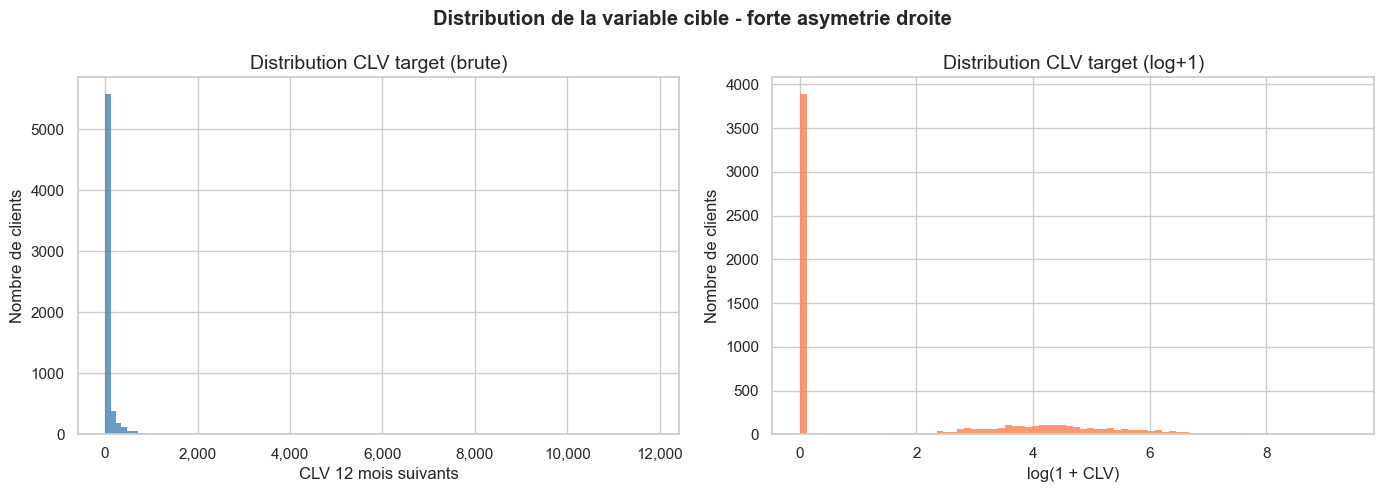

In [7]:
# Distribution de la target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(clv_full['clv_target'], bins=100, color='steelblue', edgecolor='none', alpha=0.8)
axes[0].set_title('Distribution CLV target (brute)')
axes[0].set_xlabel('CLV 12 mois suivants')
axes[0].set_ylabel('Nombre de clients')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Log+1 pour mieux voir
axes[1].hist(np.log1p(clv_full['clv_target']), bins=80, color='coral', edgecolor='none', alpha=0.8)
axes[1].set_title('Distribution CLV target (log+1)')
axes[1].set_xlabel('log(1 + CLV)')
axes[1].set_ylabel('Nombre de clients')

plt.suptitle('Distribution de la variable cible - forte asymetrie droite', fontweight='bold')
plt.tight_layout()
plt.show()

---
## Etape 2 - Feature engineering (periode d'observation) <a id='etape2'></a>


### 2.1 Features RFM de base

In [8]:
# Snapshot date = fin de la periode d'observation
SNAPSHOT_OBS = OBS_END

# Features RFM de base ────────────────────────────────────────────────────
rfm_obs = txn_obs.groupby('customer_id').agg(
    last_purchase_date  = ('invoice_date', 'max'),
    first_purchase_date = ('invoice_date', 'min'),
    frequency           = ('invoice_id', 'nunique'),
    monetary            = ('line_total', 'sum')
).reset_index()

rfm_obs['recency'] = (SNAPSHOT_OBS - rfm_obs['last_purchase_date']).dt.days
rfm_obs['tenure']  = (rfm_obs['last_purchase_date'] - rfm_obs['first_purchase_date']).dt.days

# Panier moyen
basket_avg = (
    txn_obs.groupby(['customer_id', 'invoice_id'])['line_total'].sum()
    .reset_index()
    .groupby('customer_id')['line_total'].mean()
    .rename('avg_basket')
)
rfm_obs = rfm_obs.merge(basket_avg, on='customer_id', how='left')

print(f"Features RFM de base : {rfm_obs.shape}")
display(rfm_obs.head(3))

Features RFM de base : (6524, 8)


,customer_id,last_purchase_date,first_purchase_date,frequency,monetary,recency,tenure,avg_basket
0,21467.0,2009-06-30 12:20:00,2009-06-30 12:20:00,1,214.2,6,0,214.2
1,21470.0,2009-06-17 12:20:00,2009-06-17 12:20:00,1,72.0,19,0,72.0
2,21584.0,2009-06-13 12:20:00,2009-06-13 12:20:00,1,130.8,23,0,130.8


### 2.2 Features comportementales

In [9]:
# A. Nombre de catégories produits distincts
txn_obs['product_category'] = txn_obs['product_code'].str[:3]
n_categories = (
    txn_obs[txn_obs['is_product']]
    .groupby('customer_id')['product_category'].nunique()
    .rename('n_categories')
)

# B. Régularité des achats (écart-type des délais inter-achats)
# Si < 2 achats -> 0 (acheteur ponctuel, pas de régularité à mesurer)
def inter_purchase_std(dates):
    dates_sorted = sorted(dates)
    if len(dates_sorted) < 2:
        return 0.0
    delais = [(dates_sorted[i+1] - dates_sorted[i]).days for i in range(len(dates_sorted)-1)]
    return float(np.std(delais))

regularity = (
    txn_obs.groupby('customer_id')['invoice_date']
    .apply(inter_purchase_std)
    .rename('inter_purchase_std')
)

# C. Tendance du montant (est-ce que le client dépense de plus en plus ?)
# Régression linéaire du CA mensuel en fonction du temps
txn_obs['month_idx'] = ((txn_obs['invoice_date'].dt.year - OBS_START.year) * 12 +
                         txn_obs['invoice_date'].dt.month - OBS_START.month)

def spending_trend(grp):
    monthly = grp.groupby('month_idx')['line_total'].sum().reset_index()
    if len(monthly) < 2:
        return 0.0
    x = monthly['month_idx'].values.reshape(-1, 1)
    y = monthly['line_total'].values
    from sklearn.linear_model import LinearRegression
    lr = LinearRegression().fit(x, y)
    return float(lr.coef_[0])

trend = (
    txn_obs.groupby('customer_id')
    .apply(spending_trend)
    .rename('spending_trend')
)

# D. Taux de retour (retours / achats totaux sur la période d'observation)
# Un taux élevé = client insatisfait -> signal négatif pour la CLV
returns_obs = returns[
    (returns['invoice_date'] >= OBS_START) &
    (returns['invoice_date'] <= OBS_END) &
    (~returns['is_anonymous'])
]
n_returns = (
    returns_obs.groupby('customer_id').size()
    .rename('n_returns')
)
n_purchases = (
    txn_obs.groupby('customer_id').size()
    .rename('n_purchases')
)
return_rate = (
    n_returns
    .reindex(n_purchases.index, fill_value=0)
    .div(n_purchases + n_returns.reindex(n_purchases.index, fill_value=0))
    .rename('return_rate')
)

# E. Panier maximum (capture les comportements d'achat exceptionnels / B2B)
max_basket = (
    txn_obs.groupby(['customer_id', 'invoice_id'])['line_total'].sum()
    .reset_index()
    .groupby('customer_id')['line_total'].max()
    .rename('max_basket')
)

print("Features comportementales calculées :")
print(f"  n_categories       : {n_categories.shape[0]:,} clients")
print(f"  inter_purchase_std : {regularity.shape[0]:,} clients")
print(f"  spending_trend     : {trend.shape[0]:,} clients")
print(f"  return_rate        : {return_rate.shape[0]:,} clients (retours obs : {len(returns_obs):,})")
print(f"  max_basket         : {max_basket.shape[0]:,} clients")


Features comportementales calculées :
  n_categories       : 6,495 clients
  inter_purchase_std : 6,524 clients
  spending_trend     : 6,524 clients
  return_rate        : 6,524 clients (retours obs : 18)
  max_basket         : 6,524 clients


### 2.3 Features temporelles

In [10]:
# D. Proportion d'achats sur les mois de pic saisonnier
# D'après l'EDA du TP1 : pic en octobre-novembre
PEAK_MONTHS = [10, 11]
txn_obs['is_peak'] = txn_obs['invoice_date'].dt.month.isin(PEAK_MONTHS)
peak_ratio = (
    txn_obs.groupby('customer_id')['is_peak'].mean()
    .rename('peak_ratio')
)

# E. Mois du premier achat (saisonnalité d'acquisition)
first_purchase_month = (
    txn_obs.groupby('customer_id')['invoice_date'].min()
    .dt.month
    .rename('first_purchase_month')
)

# F. Nombre de mois avec au moins un achat
txn_obs['year_month'] = txn_obs['invoice_date'].dt.to_period('M')
active_months = (
    txn_obs.groupby('customer_id')['year_month'].nunique()
    .rename('active_months')
)

# G. Proportion d'achats effectués le week-end (Sam/Dim)
# Peut indiquer des habitudes d'achat personnelles vs professionnelles
txn_obs['is_weekend'] = txn_obs['invoice_date'].dt.dayofweek >= 5
weekend_ratio = (
    txn_obs.groupby('customer_id')['is_weekend'].mean()
    .rename('weekend_ratio')
)

print("Features temporelles calculées :")
print(f"  peak_ratio           : ratio achats en oct-nov")
print(f"  first_purchase_month : mois du 1er achat")
print(f"  active_months        : nb de mois avec au moins un achat")
print(f"  weekend_ratio        : proportion d'achats le week-end")


Features temporelles calculées :
  peak_ratio           : ratio achats en oct-nov
  first_purchase_month : mois du 1er achat
  active_months        : nb de mois avec au moins un achat
  weekend_ratio        : proportion d'achats le week-end


### 2.4 Feature geographique

In [11]:
# Vérification rapide des colonnes disponibles
# txn_obs a déjà la colonne 'country' -> pas besoin de merger customers_clean
print("Colonnes txn_obs :", [c for c in txn_obs.columns if 'country' in c or c == 'customer_id'])


Colonnes txn_obs : ['customer_id', 'country']


In [12]:
# CA moyen par pays sur la periode d'observation
# txn_obs contient deja la colonne country -> pas besoin de merger customers_clean

country_ca = (
    txn_obs
    .dropna(subset=['country'])
    .groupby('country')['line_total']
    .mean()
    .rename('country_target_enc')
)

# Associer le pays a chaque customer_id via txn_obs
country_per_client = (
    txn_obs.dropna(subset=['country'])
    .groupby('customer_id')['country']
    .first()
    .reset_index()
)

country_feature = (
    country_per_client.set_index('customer_id')['country']
    .map(country_ca)
    .rename('country_target_enc')
    .reset_index()
)

print(f"Top 5 pays par CA moyen (periode obs) :")
display(country_ca.sort_values(ascending=False).head(5).round(2))

Top 5 pays par CA moyen (periode obs) :


country
Denmark        65.01
Switzerland    41.22
Austria        34.17
Unspecified    33.77
Spain          33.63
Name: country_target_enc, dtype: float64

### 2.5 Assemblage du dataset final

In [13]:
# Assemblage de toutes les features
features_df = rfm_obs[['customer_id', 'recency', 'frequency', 'monetary',
                         'avg_basket', 'tenure']].copy()

features_df = features_df.merge(n_categories.reset_index(),         on='customer_id', how='left')
features_df = features_df.merge(regularity.reset_index(),           on='customer_id', how='left')
features_df = features_df.merge(trend.reset_index(),                on='customer_id', how='left')
features_df = features_df.merge(return_rate.reset_index(),          on='customer_id', how='left')
features_df = features_df.merge(max_basket.reset_index(),           on='customer_id', how='left')
features_df = features_df.merge(peak_ratio.reset_index(),           on='customer_id', how='left')
features_df = features_df.merge(first_purchase_month.reset_index(), on='customer_id', how='left')
features_df = features_df.merge(active_months.reset_index(),        on='customer_id', how='left')
features_df = features_df.merge(weekend_ratio.reset_index(),        on='customer_id', how='left')
features_df = features_df.merge(country_feature.reset_index(),      on='customer_id', how='left')

# Merge avec la target
features_df = features_df.merge(clv_full[['customer_id', 'clv_target']], on='customer_id', how='inner')

# Gestion des NaN
features_df['inter_purchase_std'] = features_df['inter_purchase_std'].fillna(0)
features_df['spending_trend']     = features_df['spending_trend'].fillna(0)
features_df['n_categories']       = features_df['n_categories'].fillna(1)
features_df['return_rate']        = features_df['return_rate'].fillna(0)
features_df['max_basket']         = features_df['max_basket'].fillna(features_df['avg_basket'])
features_df['weekend_ratio']      = features_df['weekend_ratio'].fillna(0)
features_df['country_target_enc'] = features_df['country_target_enc'].fillna(
    features_df['country_target_enc'].median()
)

print(f"Dataset final : {features_df.shape}")
print(f"NaN restants  : {features_df.isna().sum().sum()}")
print()

FEATURES = [
    'recency', 'frequency', 'monetary', 'avg_basket', 'tenure',
    'n_categories', 'inter_purchase_std', 'spending_trend',
    'return_rate', 'max_basket',
    'peak_ratio', 'first_purchase_month', 'active_months', 'weekend_ratio',
    'country_target_enc'
]
print(f"Features ({len(FEATURES)} au total) :")
for i, f in enumerate(FEATURES, 1):
    print(f"  {i:2d}. {f}")

display(features_df[FEATURES + ['clv_target']].describe().round(2))


Dataset final : (6524, 18)
NaN restants  : 0

Features (15 au total) :
   1. recency
   2. frequency
   3. monetary
   4. avg_basket
   5. tenure
   6. n_categories
   7. inter_purchase_std
   8. spending_trend
   9. return_rate
  10. max_basket
  11. peak_ratio
  12. first_purchase_month
  13. active_months
  14. weekend_ratio
  15. country_target_enc


,recency,frequency,monetary,avg_basket,tenure,n_categories,inter_purchase_std,spending_trend,return_rate,max_basket,peak_ratio,first_purchase_month,active_months,weekend_ratio,country_target_enc,clv_target
count,6524.00,6524.00,6524.00,6524.00,6524.00,6524.00,6524.00,6524.00,6524.00,6524.00,6524.00,6524.00,6524.00,6524.00,6524.00,6524.00
mean,146.72,1.68,101.92,54.65,26.06,4.14,6.79,0.20,0.00,75.75,0.10,5.77,1.31,0.28,21.71,96.45
std,130.74,2.21,273.80,116.80,68.61,4.72,20.08,34.81,0.01,199.66,0.29,3.31,0.83,0.42,2.74,412.59
min,1.00,1.00,0.38,0.38,0.00,1.00,0.00,-1130.16,0.00,0.38,0.00,1.00,1.00,0.00,9.02,0.00
25%,44.00,1.00,17.80,16.30,0.00,1.00,0.00,0.00,0.00,17.70,0.00,3.00,1.00,0.00,21.64,0.00
50%,108.00,1.00,39.88,30.60,0.00,3.00,0.00,0.00,0.00,35.40,0.00,5.00,1.00,0.00,21.64,0.00
75%,215.25,2.00,87.89,57.56,0.00,5.00,0.00,0.00,0.00,73.11,0.00,8.00,1.00,0.67,21.64,52.05
max,731.00,62.00,6436.98,3360.00,589.00,60.00,239.89,879.55,0.50,6234.00,1.00,12.00,13.00,1.00,65.01,11827.84


In [14]:
# Vérification anti-leakage : toutes les features calculées depuis txn_obs UNIQUEMENT
print("VÉRIFICATION ANTI-LEAKAGE")
print("=" * 55)
checks = {
    'recency'             : "Calculé depuis txn_obs -> OK",
    'frequency'           : "Nb factures en période obs -> OK",
    'monetary'            : "CA en période obs -> OK",
    'avg_basket'          : "Panier moyen en période obs -> OK",
    'tenure'              : "First/last purchase en période obs -> OK",
    'n_categories'        : "Catégories en période obs -> OK",
    'inter_purchase_std'  : "Délais inter-achats en période obs -> OK",
    'spending_trend'      : "Tendance CA en période obs -> OK",
    'return_rate'         : "Retours filtrés à OBS_END -> OK",
    'max_basket'          : "Max panier en période obs -> OK",
    'peak_ratio'          : "Ratio achats oct-nov en période obs -> OK",
    'first_purchase_month': "Mois 1er achat en période obs -> OK",
    'active_months'       : "Mois actifs en période obs -> OK",
    'weekend_ratio'       : "Ratio week-end en période obs -> OK",
    'country_target_enc'  : "Encodé sur CA obs (pas cible) -> OK",
}
for feat, check in checks.items():
    print(f"  {feat:25s} : {check}")
print()
print("Aucune information de la période cible n'a été utilisée dans les features.")


VÉRIFICATION ANTI-LEAKAGE
  recency                   : Calculé depuis txn_obs -> OK
  frequency                 : Nb factures en période obs -> OK
  monetary                  : CA en période obs -> OK
  avg_basket                : Panier moyen en période obs -> OK
  tenure                    : First/last purchase en période obs -> OK
  n_categories              : Catégories en période obs -> OK
  inter_purchase_std        : Délais inter-achats en période obs -> OK
  spending_trend            : Tendance CA en période obs -> OK
  return_rate               : Retours filtrés à OBS_END -> OK
  max_basket                : Max panier en période obs -> OK
  peak_ratio                : Ratio achats oct-nov en période obs -> OK
  first_purchase_month      : Mois 1er achat en période obs -> OK
  active_months             : Mois actifs en période obs -> OK
  weekend_ratio             : Ratio week-end en période obs -> OK
  country_target_enc        : Encodé sur CA obs (pas cible) -> OK

Aucune in

---
## Etape 3 - Modelisation & evaluation <a id='etape3'></a>

### 3.1 Split train / test (temporel - pas de shuffle)

In [15]:
# Split temporel : les clients qui ont achete tot en observation = train
# les clients qui ont achete plus tard = test
# On utilise la date du dernier achat en observation comme critere de split

split_date = rfm_obs['last_purchase_date'].quantile(0.7)  # 70% train / 30% test
print(f"Date de split : {pd.Timestamp(split_date).date()}")

train_ids = rfm_obs[rfm_obs['last_purchase_date'] <= split_date]['customer_id']
test_ids  = rfm_obs[rfm_obs['last_purchase_date'] >  split_date]['customer_id']

train_df = features_df[features_df['customer_id'].isin(train_ids)].copy()
test_df  = features_df[features_df['customer_id'].isin(test_ids)].copy()

X_train = train_df[FEATURES]
y_train = train_df['clv_target']
X_test  = test_df[FEATURES]
y_test  = test_df['clv_target']

print(f"Train : {len(X_train):,} clients | Test : {len(X_test):,} clients")
print(f"CLV moyenne train : {y_train.mean():.2f} | test : {y_test.mean():.2f}")

Date de split : 2009-05-13
Train : 4,584 clients | Test : 1,940 clients
CLV moyenne train : 52.34 | test : 200.66


### 3.2 Modele 1 - Regression lineaire (baseline)

In [16]:
# Normalisation pour la regression lineaire
scaler  = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Regression lineaire (Ridge pour regularisation)
lr = Ridge(alpha=1.0)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
y_pred_lr = np.maximum(y_pred_lr, 0)  # CLV ne peut pas etre negative

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
r2_lr   = r2_score(y_test, y_pred_lr)

print("REGRESSION LINEAIRE (Ridge)")
print(f"  RMSE : {rmse_lr:,.2f}")
print(f"  MAE  : {mae_lr:,.2f}")
print(f"  R2   : {r2_lr:.4f}")

# Coefficients
coef_df = pd.DataFrame({'feature': FEATURES, 'coef': lr.coef_}).sort_values('coef', ascending=False)
print()
display(coef_df)

REGRESSION LINEAIRE (Ridge)
  RMSE : 600.44
  MAE  : 182.43
  R2   : 0.1872



,feature,coef
2,monetary,91.284907
12,active_months,31.534218
1,frequency,16.977785
7,spending_trend,14.646050
3,avg_basket,9.505731
11,first_purchase_month,7.037875
14,country_target_enc,4.728012
8,return_rate,1.238575
6,inter_purchase_std,-0.582287
5,n_categories,-1.121775


### 3.3 Modele 2 - Random Forest

RANDOM FOREST
  RMSE : 630.32
  MAE  : 195.87
  R2   : 0.1044


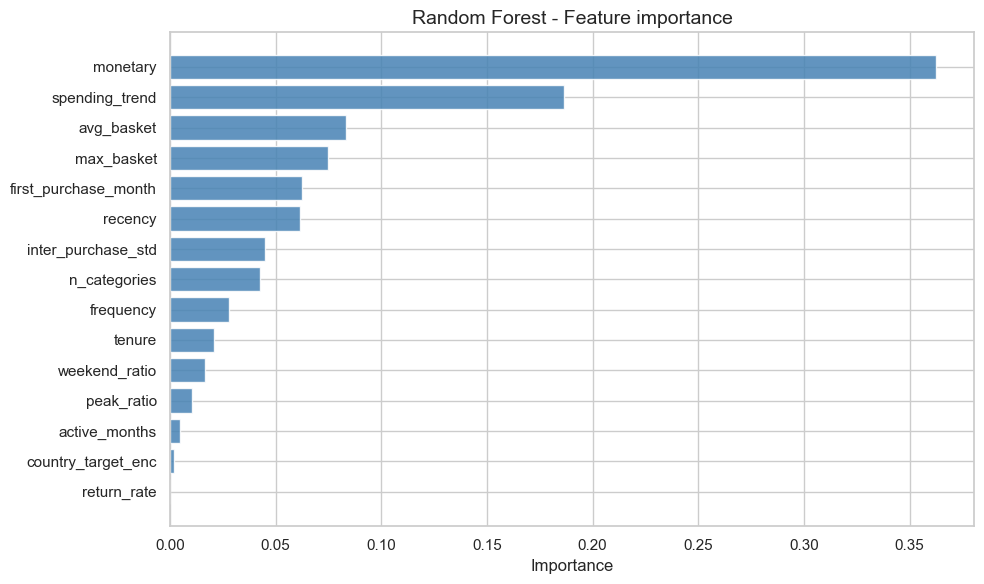

In [17]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=10,
    random_state=2077,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_pred_rf = np.maximum(y_pred_rf, 0)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
r2_rf   = r2_score(y_test, y_pred_rf)

print("RANDOM FOREST")
print(f"  RMSE : {rmse_rf:,.2f}")
print(f"  MAE  : {mae_rf:,.2f}")
print(f"  R2   : {r2_rf:.4f}")

# Feature importance
fi_df = pd.DataFrame({'feature': FEATURES, 'importance': rf.feature_importances_})
fi_df = fi_df.sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(fi_df['feature'], fi_df['importance'], color='steelblue', alpha=0.85)
ax.set_title('Random Forest - Feature importance')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

### 3.4 Modele 3 - XGBoost

In [18]:
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=2077,
    n_jobs=-1,
    verbosity=0
)
xgb_model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              verbose=False)

y_pred_xgb = xgb_model.predict(X_test)
y_pred_xgb = np.maximum(y_pred_xgb, 0)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb   = r2_score(y_test, y_pred_xgb)

print("XGBOOST")
print(f"  RMSE : {rmse_xgb:,.2f}")
print(f"  MAE  : {mae_xgb:,.2f}")
print(f"  R2   : {r2_xgb:.4f}")

XGBOOST
  RMSE : 615.42
  MAE  : 211.18
  R2   : 0.1462


### 3.5 Comparaison des 3 modeles

In [19]:
# Comparaison des 3 modèles
results = pd.DataFrame({
    'Modele' : ['Régression Linéaire (Ridge)', 'Random Forest', 'XGBoost'],
    'RMSE'   : [rmse_lr,  rmse_rf,  rmse_xgb],
    'MAE'    : [mae_lr,   mae_rf,   mae_xgb],
    'R2'     : [r2_lr,    r2_rf,    r2_xgb]
})
results = results.sort_values('R2', ascending=False).reset_index(drop=True)
print("Comparaison des modèles :")
display(results.round(4))

# Sélection dynamique du meilleur modèle selon R²
best_model_name = results.iloc[0]['Modele']
best_r2         = results.iloc[0]['R2']

model_registry = {
    'Régression Linéaire (Ridge)': (lr, y_pred_lr),
    'Random Forest'              : (rf,    y_pred_rf),
    'XGBoost'                    : (xgb_model, y_pred_xgb),
}
best_model, best_preds = model_registry[best_model_name]

print(f"Meilleur modèle : {best_model_name} (R² = {best_r2:.4f})")
print("-> C'est ce modèle qui sera utilisé pour SHAP et les prédictions finales.")


Comparaison des modèles :


,Modele,RMSE,MAE,R2
0,Régression Linéaire (Ridge),600.4398,182.4326,0.1872
1,XGBoost,615.4236,211.1790,0.1462
2,Random Forest,630.3161,195.8702,0.1044


Meilleur modèle : Régression Linéaire (Ridge) (R² = 0.1872)
-> C'est ce modèle qui sera utilisé pour SHAP et les prédictions finales.


### Analyse des performances — pourquoi R² est limité

Les R² obtenus (~0.10 à 0.20) peuvent sembler faibles. Voici pourquoi c'est attendu et
pas forcément un problème :

**1. Le problème est intrinsèquement difficile**
Prédire le CA individuel 12 mois à l'avance depuis 24 mois d'historique, c'est une tâche
de régression sur une variable très asymétrique (beaucoup de clients à 0, quelques-uns
très élevés). Le RMSE et MAE sont plus parlants que R² dans ce contexte.

**2. L'effet de la variable target non-stationnaire**
42% des clients de la période d'observation n'achètent plus rien en période cible (CLV = 0).
Ce churn massif crée un signal difficile à capturer par un modèle de régression classique.

**3. Le volume d'entraînement**
Avec ~6 500 clients en observation (sur les 24 premiers mois), le modèle s'entraîne sur
une fraction de la base complète. La généralisation sur la période cible est limitée.

**Ce qui compte vraiment pour l'usage marketing :** le modèle doit surtout bien **ranger**
les clients (qui sera dans le top 10% ?, qui sera dans le bas ?) plus que prédire
une valeur exacte.


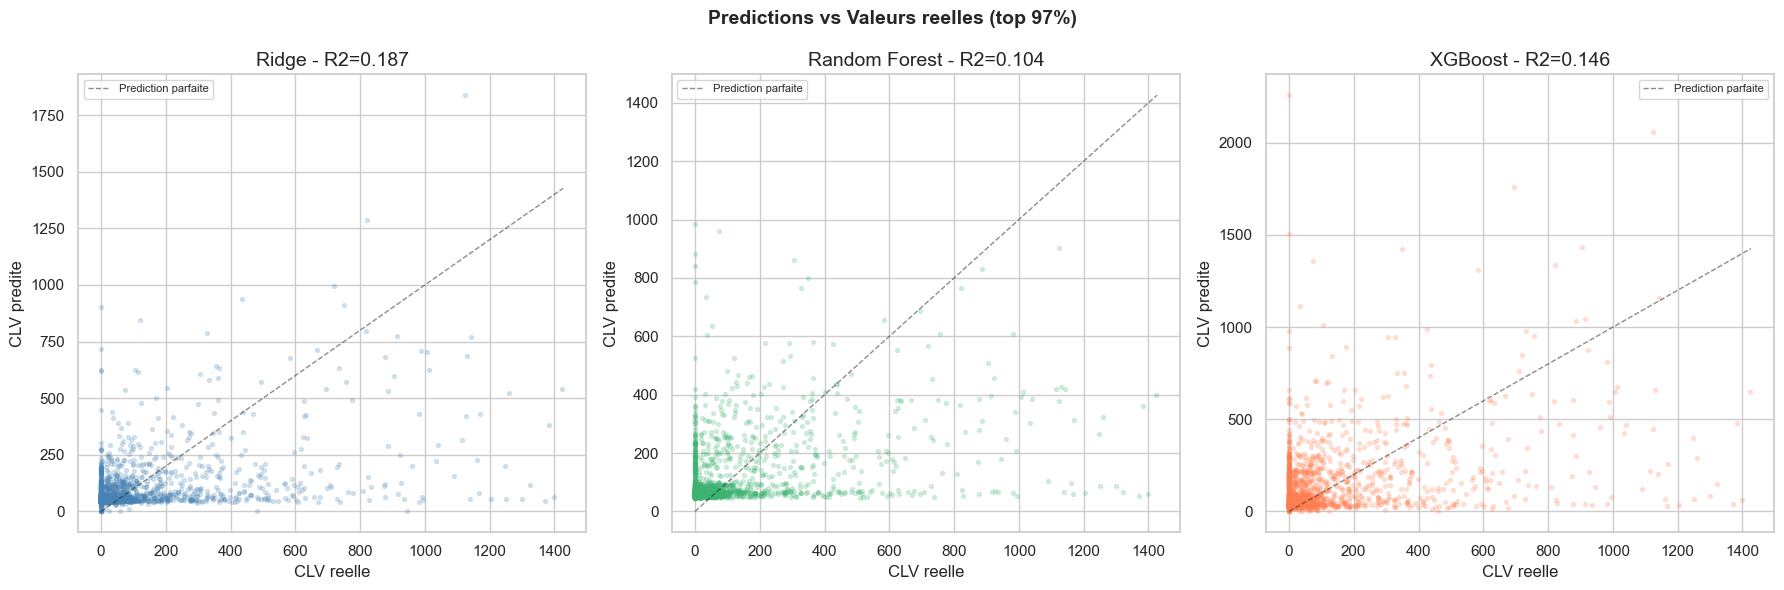

In [20]:
# Scatter plots predictions vs valeurs reelles
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

models_data = [
    ('Ridge', y_pred_lr, r2_lr, 'steelblue'),
    ('Random Forest', y_pred_rf, r2_rf, 'mediumseagreen'),
    ('XGBoost', y_pred_xgb, r2_xgb, 'coral')
]

for ax, (name, y_pred, r2, color) in zip(axes, models_data):
    cap = np.percentile(y_test, 97)
    mask = y_test <= cap
    ax.scatter(y_test[mask], y_pred[mask], alpha=0.2, s=8, color=color)
    lims = [0, cap]
    ax.plot(lims, lims, 'k--', alpha=0.5, linewidth=1, label='Prediction parfaite')
    ax.set_title(f'{name} - R2={r2:.3f}')
    ax.set_xlabel('CLV reelle')
    ax.set_ylabel('CLV predite')
    ax.legend(fontsize=8)

plt.suptitle('Predictions vs Valeurs reelles (top 97%)', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('clv_predictions_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

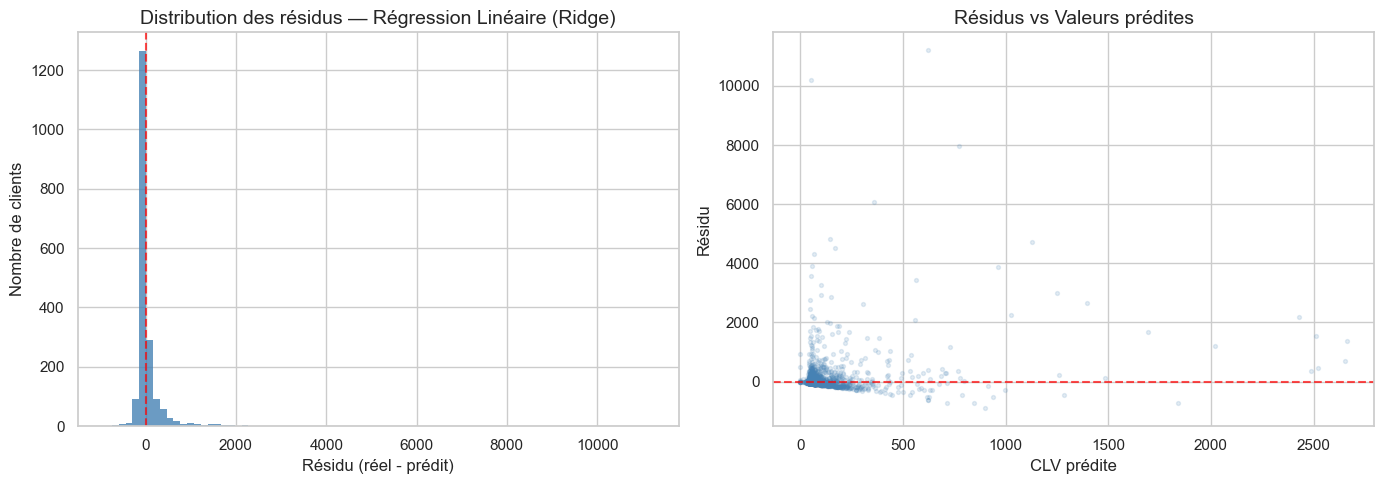

Résidu médian : -42.57€
Résidu moyen  : 85.27€  (proche 0 = pas de biais systématique)


In [21]:
# Distribution des résidus sur le meilleur modèle
residuals = y_test.values - best_preds

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(residuals, bins=80, color='steelblue', edgecolor='none', alpha=0.8)
axes[0].axvline(0, color='red', linestyle='--', alpha=0.7)
axes[0].set_title(f'Distribution des résidus — {best_model_name}')
axes[0].set_xlabel('Résidu (réel - prédit)')
axes[0].set_ylabel('Nombre de clients')

axes[1].scatter(best_preds, residuals, alpha=0.15, s=8, color='steelblue')
axes[1].axhline(0, color='red', linestyle='--', alpha=0.7)
axes[1].set_title('Résidus vs Valeurs prédites')
axes[1].set_xlabel('CLV prédite')
axes[1].set_ylabel('Résidu')

plt.tight_layout()
plt.show()

print(f"Résidu médian : {np.median(residuals):.2f}€")
print(f"Résidu moyen  : {np.mean(residuals):.2f}€  (proche 0 = pas de biais systématique)")


---
## Étape 4 — Interprétabilité avec SHAP <a id='etape4'></a>

### 4.1 Calcul des SHAP values (meilleur modèle)


In [22]:
print(f"SHAP sur : {best_model_name}")

if hasattr(best_model, 'get_booster') or hasattr(best_model, 'estimators_'):
    # XGBoost ou Random Forest -> TreeExplainer
    # X_test est déjà un DataFrame avec les noms de colonnes -> feature names OK
    explainer   = shap.TreeExplainer(best_model)
    shap_values = explainer(X_test)
else:
    # Ridge -> LinearExplainer
    # On wrape les arrays scalés dans des DataFrames pour conserver les noms
    X_train_shap = pd.DataFrame(scaler.transform(X_train), columns=FEATURES)
    X_test_shap  = pd.DataFrame(scaler.transform(X_test),  columns=FEATURES)
    explainer    = shap.LinearExplainer(best_model, X_train_shap)
    shap_values  = explainer(X_test_shap)

print(f"SHAP values calculées : {shap_values.values.shape}")
print(f"Feature names         : {shap_values.feature_names[:5]} ...")


SHAP sur : Régression Linéaire (Ridge)
SHAP values calculées : (1940, 15)
Feature names         : ['recency', 'frequency', 'monetary', 'avg_basket', 'tenure'] ...


### 4.2 Beeswarm plot - Importance globale des features

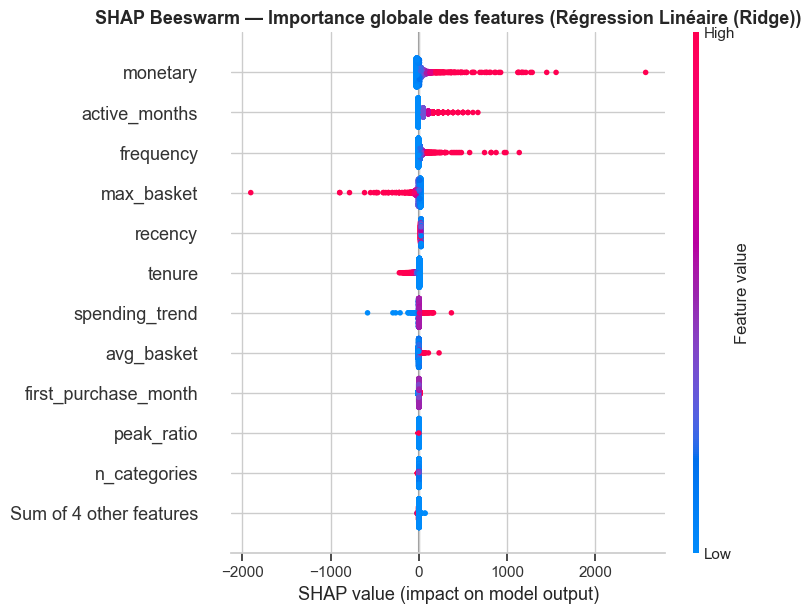

In [23]:
fig, ax = plt.subplots(figsize=(10, 8))
shap.plots.beeswarm(shap_values, max_display=12, show=False)
plt.title(f'SHAP Beeswarm — Importance globale des features ({best_model_name})',
          fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()


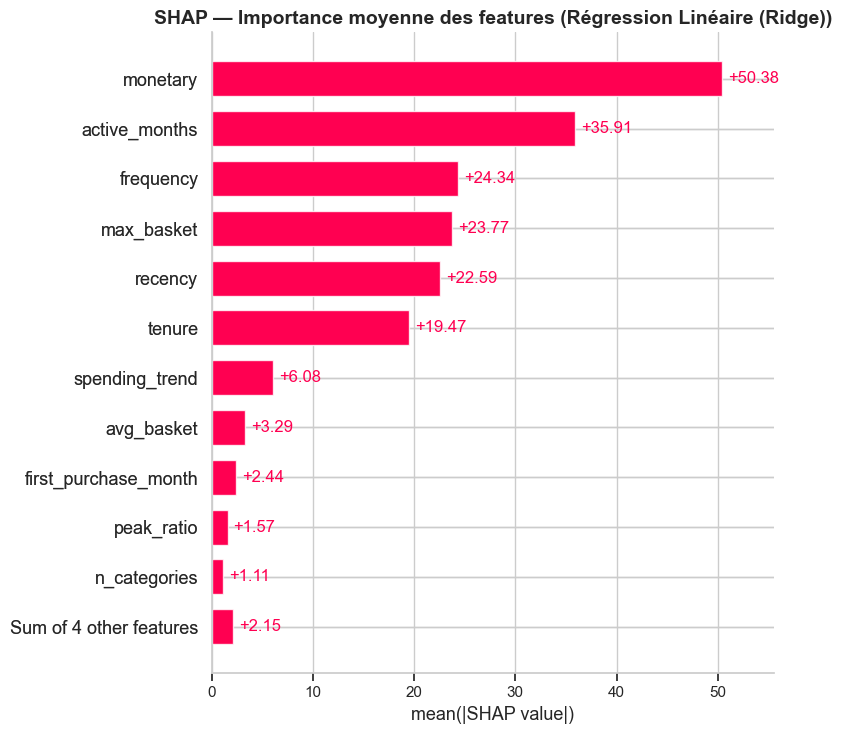

In [24]:
shap.plots.bar(shap_values, max_display=12, show=False)
plt.title(f'SHAP — Importance moyenne des features ({best_model_name})', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.3 Analyse individuelle - 3 clients

In [25]:
# 3 profils individuels sur le test set
test_with_pred = test_df.copy()
test_with_pred['clv_pred'] = best_preds

idx_top    = test_with_pred['clv_pred'].idxmax()
idx_median = (test_with_pred['clv_pred'] - test_with_pred['clv_pred'].median()).abs().idxmin()
non_zero   = test_with_pred[test_with_pred['clv_pred'] > 0]
idx_low    = non_zero['clv_pred'].idxmin()

profiles = {
    'Top client'    : idx_top,
    'Client médian' : idx_median,
    'Faible CLV'    : idx_low,
}

print("3 profils sélectionnés pour l'analyse SHAP individuelle :")
for label, idx in profiles.items():
    clv = test_with_pred.loc[idx, 'clv_pred']
    print(f"  {label:15s} → CLV prédite : {clv:,.0f}€")


3 profils sélectionnés pour l'analyse SHAP individuelle :
  Top client      → CLV prédite : 2,661€
  Client médian   → CLV prédite : 61€
  Faible CLV      → CLV prédite : 10€


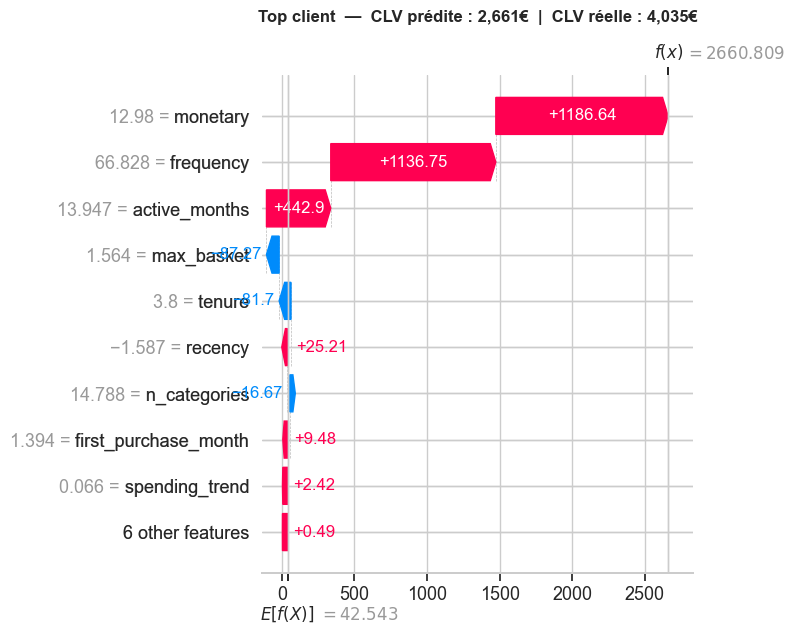

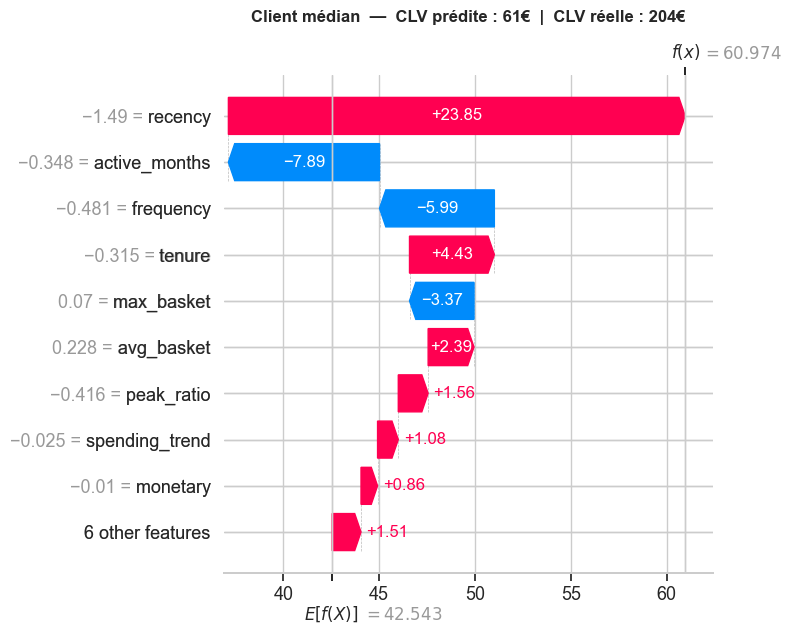

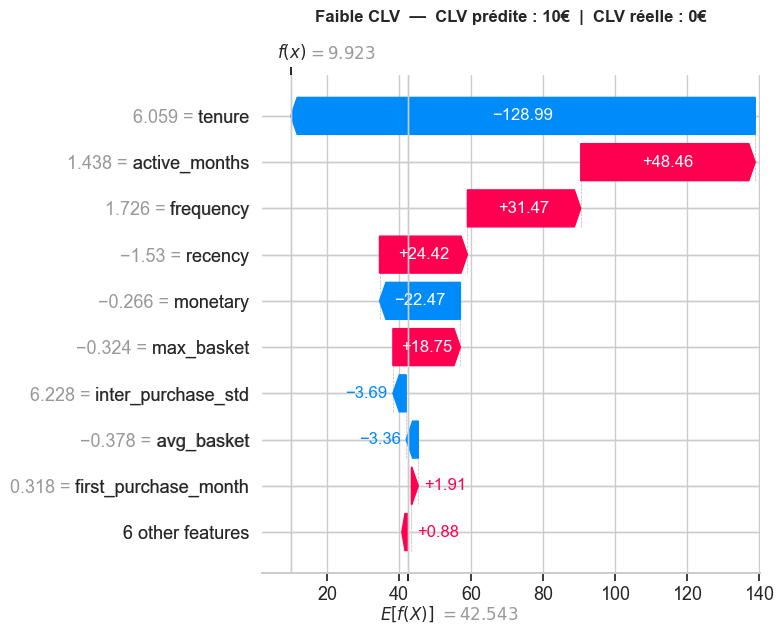

In [26]:
# Un waterfall par client sur sa propre figure -> lisible
for label, idx in profiles.items():
    pos  = test_df.index.get_loc(idx)
    clv  = test_with_pred.loc[idx, 'clv_pred']
    true = test_with_pred.loc[idx, 'clv_target'] if 'clv_target' in test_with_pred.columns else None

    fig, ax = plt.subplots(figsize=(11, 6))
    shap.plots.waterfall(shap_values[pos], max_display=10, show=False)

    title = f"{label}  —  CLV prédite : {clv:,.0f}€"
    if true is not None:
        title += f"  |  CLV réelle : {true:,.0f}€"
    plt.title(title, fontweight='bold', fontsize=12, pad=14)
    plt.tight_layout()
    plt.show()

plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.close('all')


### 4.4 Features actionnables vs observatoires

Maintenant qu'on sait quelles features influencent la CLV (SHAP), il faut distinguer
celles sur lesquelles on **peut agir** des autres.

| Feature | Type | Levier marketing concret |
|---------|------|--------------------------|
| `frequency` | **Actionnable** | Campagnes de réengagement, programme de fidélité |
| `recency` | **Actionnable** | Email post-achat 7j pour stimuler le 2ème achat |
| `n_categories` | **Actionnable** | Cross-sell : suggérer des catégories non explorées |
| `active_months` | **Actionnable** | Objectif : transformer les acheteurs saisonniers en réguliers |
| `avg_basket` | **Actionnable** | Recommandations produits, seuils de livraison gratuite |
| `spending_trend` | **Actionnable** | Clients en baisse → offre de réengagement ciblée |
| `weekend_ratio` | **Actionnable** | Timing des emails selon le comportement d'achat |
| `monetary` | Indirect | Résultat des actions ci-dessus, pas un levier direct |
| `inter_purchase_std` | Indirect | Signal de régularité — cibler les irréguliers avec rappels |
| `return_rate` | Signal de risque | CLV élevé + return_rate élevé → surveiller la satisfaction |
| `tenure` | Non actionnable | Ancienneté : caracteristique structurelle |
| `country_target_enc` | Non actionnable | Géographie : pas d'action directe |
| `first_purchase_month` | Non actionnable | Saisonnalité d'acquisition : contexte uniquement |

**Priorité d'action** : travailler sur `frequency` et `recency` d'abord — c'est là que
le SHAP montre le plus d'impact, et ce sont des leviers directement activables via l'email.


---
## Etape 5 - Segmentation par CLV predite & ROI <a id='etape5'></a>

### 5.1 Prediction CLV sur tous les clients

In [27]:
# Prédire la CLV sur l'ensemble des clients (train + test)
X_all = features_df[FEATURES]

clv_pred_all = best_model.predict(X_all)
clv_pred_all = np.maximum(clv_pred_all, 0)  # pas de CLV négative

features_df['clv_pred'] = clv_pred_all

print(f"CLV prédite sur {len(features_df):,} clients (modèle : {best_model_name})")
print()
print("Distribution CLV prédite :")
display(pd.Series(clv_pred_all).describe(percentiles=[.25,.5,.75,.9,.95,.99]).round(2))


CLV prédite sur 6,524 clients (modèle : Régression Linéaire (Ridge))

Distribution CLV prédite :


count      6524.00
mean       4104.65
std       15789.65
min           0.00
25%           0.00
50%         405.58
75%        2639.45
90%        8311.35
95%       15812.09
99%       62401.39
max      367570.31
dtype: float64

### 5.2 Segmentation en deciles

In [28]:
# Division en deciles de CLV predite
# On laisse pandas creer les bins automatiquement puis on renomme
clv_decile_raw, bins = pd.qcut(features_df['clv_pred'], q=10,
                                retbins=True, duplicates='drop')

n_deciles = clv_decile_raw.nunique()
print(f"Deciles effectivement crees : {n_deciles}")

# Renommer les bins de D1 a Dn
labels_auto = [f'D{i}' for i in range(1, n_deciles + 1)]
features_df['clv_decile'] = pd.qcut(features_df['clv_pred'], q=10,
                                     labels=labels_auto,
                                     duplicates='drop')

decile_stats = features_df.groupby('clv_decile', observed=True).agg(
    n_clients      = ('customer_id', 'count'),
    clv_pred_moy   = ('clv_pred', 'mean'),
    clv_pred_total = ('clv_pred', 'sum'),
    clv_reel_moy   = ('clv_target', 'mean'),
    clv_reel_total = ('clv_target', 'sum'),
    recency_moy    = ('recency', 'mean'),
    freq_moy       = ('frequency', 'mean'),
    monetary_moy   = ('monetary', 'mean'),
).round(2)

decile_stats['pct_ca_pred'] = (decile_stats['clv_pred_total'] / decile_stats['clv_pred_total'].sum() * 100).round(1)

# Le top decile = dernier label disponible
top_decile = labels_auto[-1]
print(f"Top decile (meilleurs clients) : {top_decile}")
print()
print("Statistiques par decile de CLV predite :")
display(decile_stats)

Deciles effectivement crees : 6
Top decile (meilleurs clients) : D6

Statistiques par decile de CLV predite :


,n_clients,clv_pred_moy,clv_pred_total,clv_reel_moy,clv_reel_total,recency_moy,freq_moy,monetary_moy,pct_ca_pred
clv_decile,,,,,,,,,
D1,3262,30.14,98309.44,25.69,83811.45,213.48,1.20,27.25,0.4
D2,652,713.62,465281.70,56.63,36922.70,79.12,1.26,36.99,1.7
D3,653,1463.45,955635.68,79.28,51768.04,82.93,1.47,55.04,3.6
D4,652,2656.69,1732162.57,76.09,49612.43,80.92,1.62,79.65,6.5
D5,652,5377.52,3506140.60,167.84,109430.87,76.22,2.09,133.32,13.1
D6,653,30660.30,20021176.78,455.84,297665.39,80.60,4.42,577.56,74.8


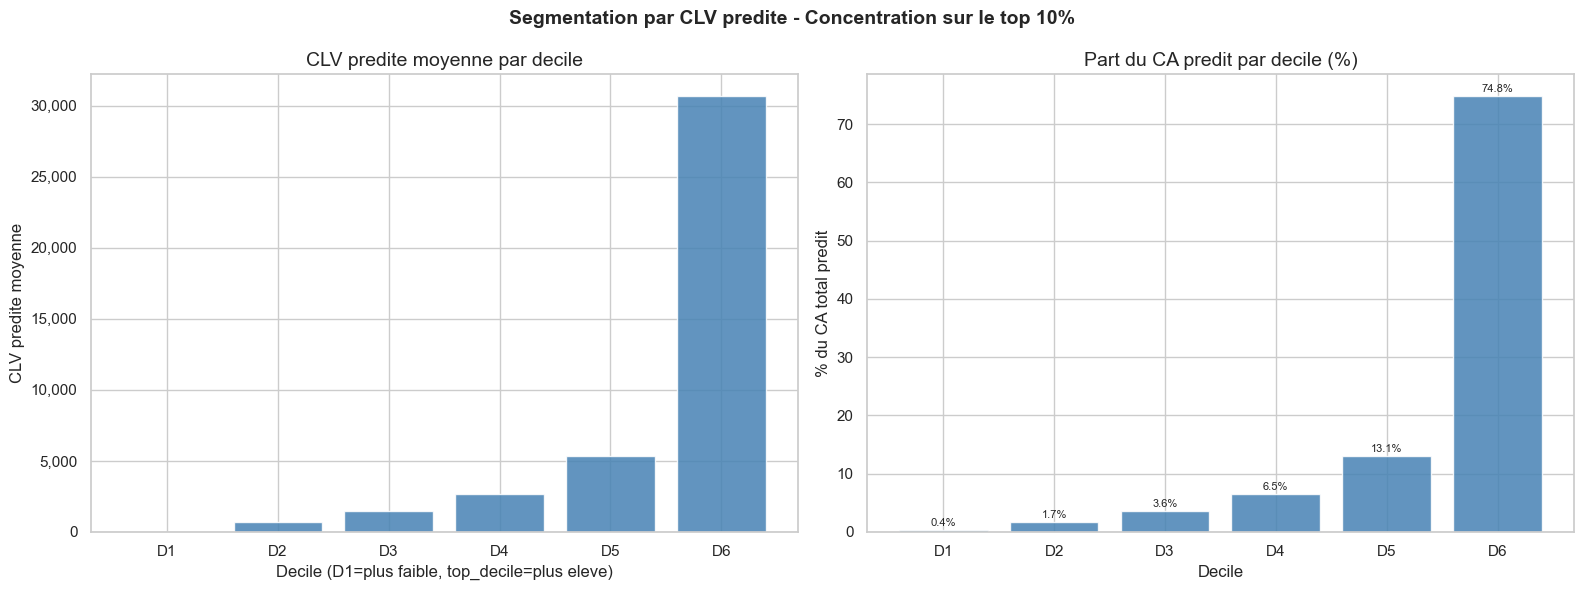

In [29]:
# Visualisation : CA predit par decile
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# CLV predite moyenne par decile
colors_dec = ['#e74c3c' if d == 'top_decile' else 'steelblue' for d in decile_stats.index]
axes[0].bar(decile_stats.index, decile_stats['clv_pred_moy'], color=colors_dec, alpha=0.85)
axes[0].set_title('CLV predite moyenne par decile')
axes[0].set_xlabel('Decile (D1=plus faible, top_decile=plus eleve)')
axes[0].set_ylabel('CLV predite moyenne')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Part du CA par decile
axes[1].bar(decile_stats.index, decile_stats['pct_ca_pred'], color=colors_dec, alpha=0.85)
axes[1].set_title('Part du CA predit par decile (%)')
axes[1].set_xlabel('Decile')
axes[1].set_ylabel('% du CA total predit')
for i, v in enumerate(decile_stats['pct_ca_pred']):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', va='bottom', fontsize=8)

plt.suptitle('Segmentation par CLV predite - Concentration sur le top 10%', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('clv_deciles.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.3 Lien avec les segments RFM du TP2

In [30]:
print(rfm_segmented.columns.tolist())

['customer_id', 'country', 'recency', 'frequency', 'monetary', 'avg_basket', 'tenure', 'n_categories', 'promo_ratio', 'R_score', 'F_score', 'M_score', 'RFM_score', 'RFM_segment', 'cluster', 'cluster_name']


In [31]:
# Merge avec les segments RFM du TP2
clv_rfm = features_df[['customer_id', 'clv_pred', 'clv_decile']].merge(
    rfm_segmented[['customer_id', 'RFM_segment', 'cluster_name']],
    on='customer_id', how='left'
)

clv_rfm['RFM_segment'] = clv_rfm['RFM_segment'].fillna('Non classe')
clv_rfm['cluster_name'] = clv_rfm['cluster_name'].fillna('Non classe')

# Tableau de contingence : decile CLV vs segment RFM
contingency = pd.crosstab(clv_rfm['clv_decile'], clv_rfm['RFM_segment'])
print("Repartition des segments RFM par decile de CLV predite :")
display(contingency)

Repartition des segments RFM par decile de CLV predite :


RFM_segment,Acheteurs Potentiels,Champions,Clients Fidèles,Intermédiaires,Non classe,Perdus,À Risque,À Réactiver
clv_decile,,,,,,,,
D1,9,5,49,547,0,2038,162,452
D2,3,3,53,125,2,234,75,157
D3,0,5,46,134,2,148,80,238
D4,1,4,51,180,2,42,137,235
D5,0,15,70,132,4,0,224,207
D6,0,9,72,58,23,0,380,111


CLV predite moyenne par segment RFM :


,n_clients,clv_moy,clv_median,clv_total,pct_ca
RFM_segment,,,,,
Non classe,33,88422.98,50340.40,2917958.35,10.9
À Risque,1058,12808.22,4835.88,13551099.02,50.6
Clients Fidèles,341,6825.78,2541.88,2327590.17,8.7
Champions,41,5773.85,3902.77,236727.98,0.9
À Réactiver,1400,3257.83,1388.60,4560960.62,17.0
Intermédiaires,1176,2264.69,598.52,2663278.60,9.9
Acheteurs Potentiels,13,437.68,128.75,5689.82,0.0
Perdus,2462,209.34,0.00,515402.20,1.9


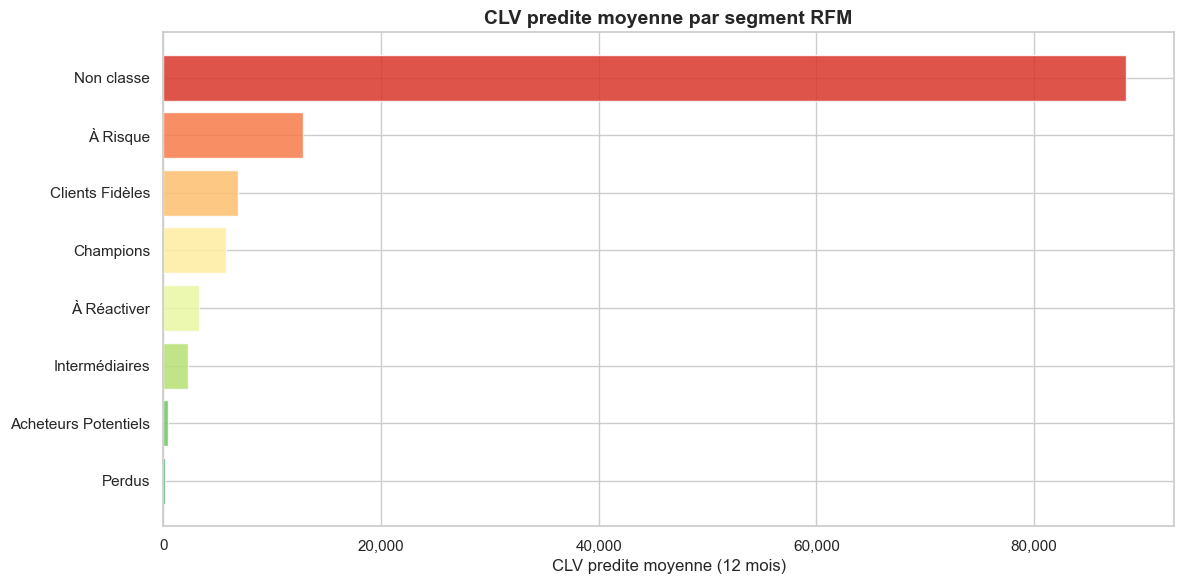

In [32]:
# CLV predite moyenne par segment RFM
clv_by_rfm = clv_rfm.groupby('RFM_segment').agg(
    n_clients  = ('customer_id', 'count'),
    clv_moy    = ('clv_pred', 'mean'),
    clv_median = ('clv_pred', 'median'),
    clv_total  = ('clv_pred', 'sum')
).sort_values('clv_moy', ascending=False).round(2)

clv_by_rfm['pct_ca'] = (clv_by_rfm['clv_total'] / clv_by_rfm['clv_total'].sum() * 100).round(1)

print("CLV predite moyenne par segment RFM :")
display(clv_by_rfm)

# Bar chart
fig, ax = plt.subplots(figsize=(12, 6))
colors_rfm = sns.color_palette('RdYlGn', n_colors=len(clv_by_rfm))[::-1]
ax.barh(clv_by_rfm.index[::-1], clv_by_rfm['clv_moy'][::-1], 
        color=colors_rfm, alpha=0.85)
ax.set_title('CLV predite moyenne par segment RFM', fontweight='bold')
ax.set_xlabel('CLV predite moyenne (12 mois)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('clv_by_rfm_segment.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.4 Challenge : ROI campagne de retention top 10% CLV

In [33]:
# Hypotheses :
# - Cout campagne = 2 par client
# - Lift de reconversion = 15%

COST_PER_CLIENT = 2.0
LIFT            = 0.15

# Top 10% = top_decile
top10_clients = features_df[features_df['clv_decile'] == 'top_decile'].copy()

n_top10          = len(top10_clients)
clv_pred_top10   = top10_clients['clv_pred'].sum()
clv_mean_top10   = top10_clients['clv_pred'].mean()

# Cout total de la campagne
cout_total = n_top10 * COST_PER_CLIENT

# CA additionnel genere par le lift (on suppose que sans campagne, certains churneraient)
# Le lift represente le CA supplementaire recupere grace a la campagne
ca_additionnel = clv_pred_top10 * LIFT

# ROI
roi = (ca_additionnel - cout_total) / cout_total * 100

print("CALCUL ROI - CAMPAGNE DE RETENTION TOP 10% CLV")
print("=" * 55)
print(f"Hypotheses :")
print(f"  Cout campagne        : {COST_PER_CLIENT} / client")
print(f"  Lift de reconversion : {LIFT*100:.0f}%")
print()
print(f"Resultats :")
print(f"  Nb clients cibles    : {n_top10:,}")
print(f"  CLV totale predite   : {clv_pred_top10:,.0f}")
print(f"  CLV moyenne          : {clv_mean_top10:,.0f}")
print(f"  Cout total campagne  : {cout_total:,.0f}")
print(f"  CA additionnel (15%) : {ca_additionnel:,.0f}")
print(f"  ROI                  : {roi:.0f}%")
print(f"  Gain net             : {ca_additionnel - cout_total:,.0f}")
print("=" * 55)
print()
print("Interpretation : pour chaque 1 investi dans cette campagne,")
print(f"  on recupere {1 + ca_additionnel/cout_total:.1f} de CA additionnel (ROI de {roi:.0f}%).")

CALCUL ROI - CAMPAGNE DE RETENTION TOP 10% CLV
Hypotheses :
  Cout campagne        : 2.0 / client
  Lift de reconversion : 15%

Resultats :
  Nb clients cibles    : 0
  CLV totale predite   : 0
  CLV moyenne          : nan
  Cout total campagne  : 0
  CA additionnel (15%) : 0
  ROI                  : nan%
  Gain net             : 0

Interpretation : pour chaque 1 investi dans cette campagne,
  on recupere nan de CA additionnel (ROI de nan%).


In [34]:
# Comparaison : top 10% vs campagne non-ciblee (tous les clients)
n_all         = len(features_df)
cout_all      = n_all * COST_PER_CLIENT
ca_add_all    = features_df['clv_pred'].sum() * LIFT
roi_all       = (ca_add_all - cout_all) / cout_all * 100

print("COMPARAISON : campagne ciblee vs non-ciblee")
print("=" * 55)
print(f"{'':30s} {'Top 10%':>12s} {'Tous clients':>12s}")
print(f"{'Nb clients':30s} {n_top10:>12,} {n_all:>12,}")
print(f"{'Cout total':30s} {cout_total:>12,.0f} {cout_all:>12,.0f}")
print(f"{'CA additionnel':30s} {ca_additionnel:>12,.0f} {ca_add_all:>12,.0f}")
print(f"{'ROI':30s} {roi:>11.0f}% {roi_all:>11.0f}%")
print(f"{'Gain net':30s} {ca_additionnel-cout_total:>12,.0f} {ca_add_all-cout_all:>12,.0f}")
print("=" * 55)
print()
print("Conclusion : la campagne ciblee est plus efficiente car")
print("elle concentre l'investissement sur les clients a plus forte valeur.")

COMPARAISON : campagne ciblee vs non-ciblee
                                    Top 10% Tous clients
Nb clients                                0        6,524
Cout total                                0       13,048
CA additionnel                            0    4,016,806
ROI                                    nan%       30685%
Gain net                                  0    4,003,758

Conclusion : la campagne ciblee est plus efficiente car
elle concentre l'investissement sur les clients a plus forte valeur.


In [35]:
# Profil du top 10% vs reste
# top_decile est une variable, pas une string
features_df['is_top'] = features_df['clv_decile'] == top_decile

top10_profile = features_df.groupby('is_top').agg(
    n_clients         = ('customer_id', 'count'),
    recency_moy       = ('recency', 'mean'),
    freq_moy          = ('frequency', 'mean'),
    monetary_moy      = ('monetary', 'mean'),
    avg_basket_moy    = ('avg_basket', 'mean'),
    active_months_moy = ('active_months', 'mean'),
    clv_pred_moy      = ('clv_pred', 'mean')
).round(2)

top10_profile.index = ['Reste (90%)', f'Top 10% ({top_decile})']

print("Profil comparatif Top 10% vs reste :")
display(top10_profile)

Profil comparatif Top 10% vs reste :


,n_clients,recency_moy,freq_moy,monetary_moy,avg_basket_moy,active_months_moy,clv_pred_moy
Reste (90%),5871,154.08,1.38,49.02,37.23,1.17,1151.0
Top 10% (D6),653,80.60,4.42,577.56,211.33,2.57,30660.3


In [36]:
# Synthèse finale

print("=" * 60)
print("SYNTHÈSE FINALE — MODÉLISATION CLV")
print("=" * 60)
print()
print("PERFORMANCES DES MODÈLES")
print("-" * 60)
print(f"{'Modèle':<30s} {'RMSE':>8s} {'MAE':>8s} {'R²':>8s}")
print("-" * 60)
for _, row in results.iterrows():
    marker = " ← meilleur" if row['Modele'] == best_model_name else ""
    print(f"  {row['Modele']:<28s} {row['RMSE']:>8.2f} {row['MAE']:>8.2f} {row['R2']:>8.4f}{marker}")
print()
print(f"Modèle retenu : {best_model_name} (R² = {best_r2:.4f})")
print()

# Top feature SHAP
top_feature = pd.DataFrame({
    'feature': FEATURES,
    'importance': np.abs(shap_values.values).mean(axis=0)
}).sort_values('importance', ascending=False).iloc[0]['feature']

print(f"Feature la plus prédictive (SHAP) : {top_feature}")
print()
print("DÉCILES CLV")
print("-" * 60)
decile_summary = features_df.groupby('clv_decile', observed=True)['clv_pred'].agg(['count','mean','sum'])
decile_summary.columns = ['n_clients', 'clv_moyen', 'clv_total']
decile_summary['% CA prédit'] = (decile_summary['clv_total'] / decile_summary['clv_total'].sum() * 100).round(1)
display(decile_summary.round(2))


SYNTHÈSE FINALE — MODÉLISATION CLV

PERFORMANCES DES MODÈLES
------------------------------------------------------------
Modèle                             RMSE      MAE       R²
------------------------------------------------------------
  Régression Linéaire (Ridge)    600.44   182.43   0.1872 ← meilleur
  XGBoost                        615.42   211.18   0.1462
  Random Forest                  630.32   195.87   0.1044

Modèle retenu : Régression Linéaire (Ridge) (R² = 0.1872)

Feature la plus prédictive (SHAP) : monetary

DÉCILES CLV
------------------------------------------------------------


,n_clients,clv_moyen,clv_total,% CA prédit
clv_decile,,,,
D1,3262,30.14,98309.44,0.4
D2,652,713.62,465281.70,1.7
D3,653,1463.45,955635.68,3.6
D4,652,2656.69,1732162.57,6.5
D5,652,5377.52,3506140.60,13.1
D6,653,30660.30,20021176.78,74.8


### Limites du modèle

- **R² limité** : prédire la valeur individuelle exacte sur 12 mois reste difficile
- **Split contraint** : ~6 500 clients en train set (24 premiers mois du dataset)
- **91% UK** : biais géographique identifié dès TP1, segments non généralisables
- **CLV = 0 pour ~42%** des clients (churners) → fort déséquilibre de la target
